In [1]:
import gpt as g
import numpy as np
import qlat as q
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.linalg import inv
from scipy.linalg import eigh
from scipy.stats import f as fdist
from abc import ABC, abstractmethod
from jackknife import *

SharedMemoryMpi:  World communicator of size 1
SharedMemoryMpi:  Node  communicator of size 1
SharedMemoryMpi: SharedMemoryAllocate 1073741824 MMAP anonymous implementation 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the terms of the 

### Functions

In [38]:
dst_Vsub = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p"
ld = q.load_lat_data(dst_Vsub + f"/traj-1102/pipi_vev.lat")
ld.info()[0][2]

['< 1 >  exprs[0]',
 '< sigma(-tsep) >  exprs[1]',
 '< sigma^dag(0) >  exprs[2]',
 '< wf_src(0) * pipi_i0(-tsep) >  exprs[3]',
 '< wf_snk(0) * pipi_i0^dag(0) >  exprs[4]',
 '< wf_src(1) * pipi_i0(-tsep) >  exprs[5]',
 '< wf_snk(1) * pipi_i0^dag(0) >  exprs[6]',
 '< wf_src(2) * pipi_i0(-tsep) >  exprs[7]',
 '< wf_snk(2) * pipi_i0^dag(0) >  exprs[8]',
 '< wf_src(3) * pipi_i0(-tsep) >  exprs[9]',
 '< wf_snk(3) * pipi_i0^dag(0) >  exprs[10]']

### Load data

In [20]:
#sigma-sigma data is ina different place than the pipi data
dst_sigma = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma/"
dst_sigma2 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-sigma-2/"

# D = 5 data is split
dst_pipi = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-I0D5-p"
dst_Vsub = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-pipi-V"

sigma_ld = []
sigma2_ld = []
pipi_ld = []
vev_ld = []
Vsub_ld = []

for traj in range(1102,1483,10):
    if traj == 1162:
        continue
    #print(traj)
    dst_s = dst_sigma + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    dst_s2 = dst_sigma + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    dst_pp = dst_pipi + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
    dst_vev = dst_pipi + f"/traj-{traj}/pipi_vev.lat"
    dst_vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
    
    sigma_ld.append(q.load_lat_data(dst_s).to_numpy())
    sigma2_ld.append(q.load_lat_data(dst_s2).to_numpy())
    pipi_ld.append(q.load_lat_data(dst_pp).to_numpy())
    vev_ld.append(q.load_lat_data(dst_vev).to_numpy())
    Vsub_ld.append(q.load_lat_data(dst_vsub).to_numpy())

omit = [1645, 1655, 1665, 1675, 1685, 1695, 2035, 2075]

for traj in range(1505,2176,10):
    if traj in omit:
        continue
    #print(traj)
    dst_s = dst_sigma + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    dst_s2 = dst_sigma + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    dst_pp = dst_pipi + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
    dst_vev = dst_pipi + f"/traj-{traj}/pipi_vev.lat"
    dst_vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
    
    sigma_ld.append(q.load_lat_data(dst_s).to_numpy())
    sigma2_ld.append(q.load_lat_data(dst_s2).to_numpy())
    pipi_ld.append(q.load_lat_data(dst_pp).to_numpy())
    vev_ld.append(q.load_lat_data(dst_vev).to_numpy())
    Vsub_ld.append(q.load_lat_data(dst_vsub).to_numpy())

for traj in range(975,1096,10):
    #print(traj)
    dst_s = dst_sigma + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    dst_s2 = dst_sigma + f"/traj-{traj}/meson_corr_psnk_psrc_mom.lat"
    dst_pp = dst_pipi + f"/traj-{traj}/pipi_corr_psnk_psrc.lat"
    dst_vev = dst_pipi + f"/traj-{traj}/pipi_vev.lat"
    dst_vsub = dst_Vsub + f"/traj-{traj}/vac_corr_psnk_psrc.lat"
    
    sigma_ld.append(q.load_lat_data(dst_s).to_numpy())
    sigma2_ld.append(q.load_lat_data(dst_s2).to_numpy())
    pipi_ld.append(q.load_lat_data(dst_pp).to_numpy())
    vev_ld.append(q.load_lat_data(dst_vev).to_numpy())
    Vsub_ld.append(q.load_lat_data(dst_vsub).to_numpy())


sigma_arr = np.array(sigma_ld)
sigma2_arr = np.array(sigma2_ld)
pipi_arr = np.array(pipi_ld)
vev_arr = np.array(vev_ld)
vsub_arr = np.array(Vsub_ld)

print(vsub_arr.shape)

#missing 1162, 1492 in pipi-V. 

(111, 25, 20)


### Sigma

In [26]:
#function that completes the counter normalization for an array with shape
# [njkblks, nexpr, ... ] where the 0th expression is always <1> 
def counter_norm(jk_arr):
    tol = 1e-12
    #split counters and other correlators
    counter_jks = jk_arr[:,0,...]
    corr_jks = jk_arr[:,1:,...] 
    corr_norm = np.zeros_like(corr_jks)
    nexpr = corr_jks.shape[1]

    for expr in range(nexpr):
        corr_norm[:,expr,...] = np.divide(corr_jks[:,expr,...], counter_jks, where=(counter_jks>tol))
        
    return corr_norm

#function that adds the two types of the sigma correlator given arrays of shape (ncf,nt) for both inputs. 
def sigma_type_add(sigma_t1, sigma_vac):
    ncf = sigma_t1.shape[0]
    nt = sigma_t1.shape[1]

    sigma_total = np.zeros_like(sigma_t1)
    
    for cf in range(ncf):
        sigma_total[cf,:] = sigma_t1[cf,:] + sigma_vac[cf,:]

    return sigma_total

In [66]:
np.average(sig_vac_sub[0,20:80])

np.complex128(1.925017960851447e-07+4.6577046772961156e-08j)

In [67]:
sig_vev = vev_arr[:,:3,...]

sig_vev_norm = counter_norm(sig_vev)
print(sig_vev_norm.shape)

sig_sub_term = sub_term(sig_vev_norm[:,0,:], sig_vev_norm[:,1,:], Delta=0)

sig_vac_sub = sigma_norm[:,2,:] - sig_sub_term

sig_vacsub_avg, sig_vacsub_err = jack_all(sig_vac_sub.real)
print(sig_vacsub_avg.shape)

(111, 2, 96)
(111, 96)
(111, 96)
Subtraction term standard deviation: 5.637326363928673e-06
(96,)


In [62]:
sigma_jks = jackblocks_all(sigma_arr,omit=[])

#counter normalization
sigma_norm = counter_norm(sigma_jks)

sigma_avg, sigma_err = jack_all(sigma_norm.real)
print(sigma_avg.shape)

(4, 96)


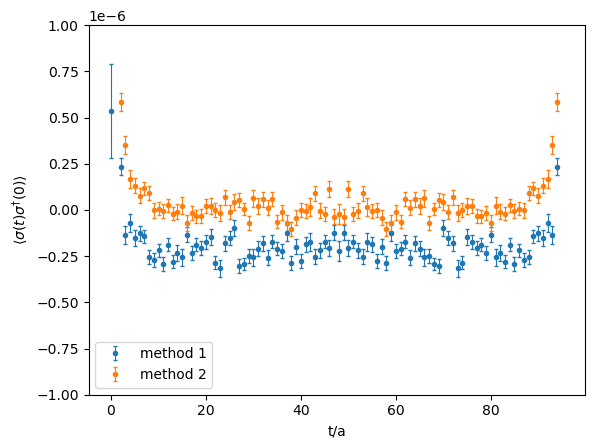

In [64]:
t = np.linspace(0,95,96)
fig, ax = plt.subplots()

ax.errorbar(t, sig_vacsub_avg, yerr=sigma_err[3,:], marker='.', ls='',elinewidth=0.8, capsize=1.5, label="method 1")
ax.errorbar(t, sigma_avg[3,:], yerr=sigma_err[3,:],marker='.', ls='',elinewidth=0.8, capsize=1.5, label="method 2")

ax.set_xlabel('t/a')
ax.set_ylabel(r'$\langle \sigma(t) \sigma^{\dagger}(0) \rangle$')
ax.set_ylim(-1e-6, 1e-6)
ax.legend()

### Diagonal pipi terms